# 03 - Modeling

Builds on `01_eda.ipynb` and `02_feature_engineering.ipynb`. This notebook:

1. Loads the processed feature tables from `data/processed/`.
2. Establishes a naive baseline for context.
3. Compares several candidate models on the **time-based holdout** split (never on validation - that split exists purely so this comparison is honest).
4. Tests whether excluding the flagged rate-per-mile outlier rows from training helps.
5. Selects a final model for the full feature set, and a separate **no-market-signal fallback model** for December (which never has `market_index`/`quote_signal`).
6. Retrains both on all available labeled data and generates the two required deliverables:
   - `validation_predictions.csv` (load_id, predicted_rate for all 12,000 validation loads)
   - the completed December file, then runs `score.py` to validate format and produce the required chart.
7. Saves the final fitted models for the repo.

## 1. Setup & Imports

In [ ]:
import pickle
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 2. Load Processed Data

In [25]:
PROCESSED_DIR = Path("../data/processed")

dev = pd.read_csv(PROCESSED_DIR / "dev_features.csv")
holdout = pd.read_csv(PROCESSED_DIR / "holdout_features.csv")
train_full = pd.read_csv(PROCESSED_DIR / "train_features_full.csv")
train_no_market = pd.read_csv(PROCESSED_DIR / "train_features_no_market.csv")
validation = pd.read_csv(PROCESSED_DIR / "validation_features.csv")
december = pd.read_csv(PROCESSED_DIR / "december_features.csv")

with open(PROCESSED_DIR / "feature_config.pkl", "rb") as f:
    feature_config = pickle.load(f)

FULL_FEATURES = feature_config["model_feature_cols_full"]
NO_MARKET_FEATURES = feature_config["model_feature_cols_no_market"]

print("dev:", dev.shape, " holdout:", holdout.shape)
print("train_full:", train_full.shape, " train_no_market:", train_no_market.shape)
print("validation:", validation.shape, " december:", december.shape)
print()
print("Full feature set     :", FULL_FEATURES)
print("No-market feature set:", NO_MARKET_FEATURES)

dev: (41468, 30)  holdout: (6532, 30)
train_full: (48000, 30)  train_no_market: (48000, 25)
validation: (12000, 28)  december: (31, 19)

Full feature set     : ['distance', 'log_distance', 'weight', 'weight_missing', 'market_index', 'market_index_missing', 'quote_signal', 'market_index_x_distance', 'quote_signal_x_distance', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'days_since_start', 'equip_Dry_Van', 'equip_Reefer', 'equip_Flatbed', 'pickup_te', 'delivery_te']
No-market feature set: ['distance', 'log_distance', 'weight', 'weight_missing', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'days_since_start', 'equip_Dry_Van', 'equip_Reefer', 'equip_Flatbed', 'pickup_te', 'delivery_te']


## 3. Evaluation Utilities

Four metrics are tracked throughout:
- **MAE** ($) - average absolute dollar error, easy to communicate.
- **RMSE** ($) - penalizes large misses more, sensitive to the rate-per-mile outlier rows.
- **MAPE** (%) - scale-free, easiest to compare across the wide range of `posted_rate` values ($57 to $25,533).
- **R²** - overall variance explained, for a single-number sanity check.

In [26]:
def evaluate(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    if label:
        print(f"{label:42s} MAE=${mae:8.2f}   RMSE=${rmse:8.2f}   MAPE={mape:6.2f}%   R2={r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}


def fit_predict(model, X_train, y_train, X_test, log_target=False):
    y_fit = np.log1p(y_train) if log_target else y_train
    model.fit(X_train, y_fit)
    pred = model.predict(X_test)
    if log_target:
        pred = np.expm1(pred)
    return pred

## 4. Naive Baseline

A model that just predicts the training mean for every row - this is the floor any real model needs to beat by a wide margin, and gives the error metrics above some context.

In [27]:
baseline_pred = np.full(len(holdout), dev["posted_rate"].mean())
_ = evaluate(holdout["posted_rate"], baseline_pred, "Mean baseline")

Mean baseline                              MAE=$ 1179.89   RMSE=$ 1525.64   MAPE= 84.69%   R2=-0.0001


## 5. Candidate Models - Full Feature Set

Four model families are compared, each with both the raw target and a `log1p(posted_rate)` target (the EDA found the target right-skewed, so a log target is a natural thing to test rather than assume). All are trained on `dev` and scored on `holdout` - the time-based split from the feature engineering notebook, so this comparison reflects genuine forward-in-time forecasting, matching how the model will actually be used on `validation.csv` and December.

In [28]:
X_dev, y_dev = dev[FULL_FEATURES], dev["posted_rate"]
X_holdout, y_holdout = holdout[FULL_FEATURES], holdout["posted_rate"]

candidates = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_depth=8, learning_rate=0.06, max_iter=400, random_state=RANDOM_STATE
    ),
}

results = []
for name, model in candidates.items():
    for log_target in (False, True):
        pred = fit_predict(model, X_dev, y_dev, X_holdout, log_target=log_target)
        metrics = evaluate(y_holdout, pred, f"{name} ({'log' if log_target else 'raw'} target)")
        results.append({"model": name, "target": "log" if log_target else "raw", **metrics})

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

Linear Regression (raw target)             MAE=$  147.12   RMSE=$  633.81   MAPE=  8.05%   R2=0.8274
Linear Regression (log target)             MAE=$  124.89   RMSE=$  630.83   MAPE=  5.76%   R2=0.8290
Ridge (raw target)                         MAE=$  147.11   RMSE=$  633.81   MAPE=  8.05%   R2=0.8274
Ridge (log target)                         MAE=$  125.26   RMSE=$  630.97   MAPE=  5.77%   R2=0.8289
Random Forest (raw target)                 MAE=$  171.99   RMSE=$  650.27   MAPE=  8.08%   R2=0.8183
Random Forest (log target)                 MAE=$  158.83   RMSE=$  645.51   MAPE=  7.22%   R2=0.8210
HistGradientBoosting (raw target)          MAE=$  147.78   RMSE=$  636.50   MAPE=  6.70%   R2=0.8259
HistGradientBoosting (log target)          MAE=$  129.49   RMSE=$  632.91   MAPE=  5.93%   R2=0.8279


,model,target,MAE,RMSE,MAPE,R2
1,Linear Regression,log,124.887847,630.826053,5.758939,0.829009
3,Ridge,log,125.259193,630.967877,5.771270,0.828932
7,HistGradientBoosting,log,129.493954,632.913367,5.926415,0.827876
2,Ridge,raw,147.105415,633.812893,8.049651,0.827386
0,Linear Regression,raw,147.118529,633.808267,8.051108,0.827389
6,HistGradientBoosting,raw,147.779397,636.498775,6.700190,0.825920
5,Random Forest,log,158.832487,645.505970,7.223567,0.820958
4,Random Forest,raw,171.989738,650.272318,8.084453,0.818305


## 6. Effect of Excluding Rate-per-Mile Outlier Rows from Training

Section 14 of the EDA flagged 671 training rows (1.40%) with a rate-per-mile far outside the tight band the rest of the data follows. `is_rpm_outlier` (built in the feature engineering notebook) makes it easy to test whether **excluding** them from training helps, while `holdout` itself is left untouched - the goal is a model that predicts holdout well, not one that's simply easier to fit.

In [29]:
dev_no_outliers = dev[dev["is_rpm_outlier"] == 0]
X_dev_clean = dev_no_outliers[FULL_FEATURES]
y_dev_clean = dev_no_outliers["posted_rate"]

print(f"Training rows: {len(dev):,} -> {len(dev_no_outliers):,} after removing flagged outliers")
print()

outlier_results = []
for name, model in candidates.items():
    pred_kept = fit_predict(model, X_dev, y_dev, X_holdout, log_target=True)
    metrics_kept = evaluate(y_holdout, pred_kept, f"{name} (log, outliers kept)")

    pred_removed = fit_predict(model, X_dev_clean, y_dev_clean, X_holdout, log_target=True)
    metrics_removed = evaluate(y_holdout, pred_removed, f"{name} (log, outliers removed)")

    outlier_results.append({"model": name, "outliers": "kept", **metrics_kept})
    outlier_results.append({"model": name, "outliers": "removed", **metrics_removed})
    print()

pd.DataFrame(outlier_results).sort_values("MAE")

Training rows: 41,468 -> 40,898 after removing flagged outliers

Linear Regression (log, outliers kept)     MAE=$  124.89   RMSE=$  630.83   MAPE=  5.76%   R2=0.8290
Linear Regression (log, outliers removed)  MAE=$  120.34   RMSE=$  628.58   MAPE=  5.57%   R2=0.8302

Ridge (log, outliers kept)                 MAE=$  125.26   RMSE=$  630.97   MAPE=  5.77%   R2=0.8289
Ridge (log, outliers removed)              MAE=$  120.49   RMSE=$  628.69   MAPE=  5.57%   R2=0.8302

Random Forest (log, outliers kept)         MAE=$  158.83   RMSE=$  645.51   MAPE=  7.22%   R2=0.8210
Random Forest (log, outliers removed)      MAE=$  124.93   RMSE=$  633.17   MAPE=  5.56%   R2=0.8277

HistGradientBoosting (log, outliers kept)  MAE=$  129.49   RMSE=$  632.91   MAPE=  5.93%   R2=0.8279
HistGradientBoosting (log, outliers removed) MAE=$  137.54   RMSE=$  631.10   MAPE=  6.28%   R2=0.8289



,model,outliers,MAE,RMSE,MAPE,R2
1,Linear Regression,removed,120.344289,628.583296,5.568197,0.830223
3,Ridge,removed,120.489986,628.694250,5.573125,0.830163
0,Linear Regression,kept,124.887847,630.826053,5.758939,0.829009
5,Random Forest,removed,124.932367,633.167091,5.556603,0.827738
2,Ridge,kept,125.259193,630.967877,5.771270,0.828932
6,HistGradientBoosting,kept,129.493954,632.913367,5.926415,0.827876
7,HistGradientBoosting,removed,137.537092,631.097995,6.275014,0.828862
4,Random Forest,kept,158.832487,645.505970,7.223567,0.820958


## 7. Selecting the Final Model - Full Feature Set

**Chosen: Linear Regression on `log1p(posted_rate)`, trained with the flagged rate-per-mile outlier rows excluded.**

Reasoning:
- It has the lowest (or statistically tied-for-lowest) MAE, RMSE, and MAPE of every combination tested above - the extra flexibility of Random Forest / HistGradientBoosting doesn't translate into better holdout accuracy here, most likely because the engineered features (`log_distance`, the `* distance` market-signal interactions, target-encoded cities) already capture the non-linear structure the EDA found, leaving a largely linear relationship for the model to fit in log-space.
- Removing the flagged outlier rows from training measurably helps this model - consistent with those rows being noise rather than a pattern worth fitting.
- It is fully transparent: every prediction can be explained as a sum of coefficients × features, which matters both for sanity-checking the December extrapolation and for explaining the model in the Loom walkthrough.
- It's fast to retrain and has no random-seed sensitivity to worry about in the final submission.

This choice is revisited below for the no-market fallback model using the same evidence-based approach.

In [30]:
final_model_full = LinearRegression()
final_model_full.fit(X_dev_clean, np.log1p(y_dev_clean))

holdout_pred_final = np.expm1(final_model_full.predict(X_holdout))
final_holdout_metrics = evaluate(y_holdout, holdout_pred_final, "FINAL full-feature model (holdout)")

FINAL full-feature model (holdout)         MAE=$  120.34   RMSE=$  628.58   MAPE=  5.57%   R2=0.8302


## 8. Model Coefficients - Interpretability Check

In [31]:
coef_table = pd.DataFrame({
    "feature": FULL_FEATURES,
    "coefficient": final_model_full.coef_,
}).sort_values("coefficient", key=np.abs, ascending=False)

coef_table

,feature,coefficient
1,log_distance,0.852872
4,market_index,0.162293
14,equip_Dry_Van,-0.065974
15,equip_Reefer,0.053853
6,quote_signal,0.025837
16,equip_Flatbed,0.012120
9,month_sin,0.003710
12,dow_cos,0.003551
11,dow_sin,-0.002338
3,weight_missing,0.002319


In [32]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
coef_table.set_index("feature")["coefficient"].sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Linear Regression Coefficients (log-target model)")
plt.xlabel("Coefficient (effect on log(posted_rate))")
plt.tight_layout()
plt.show()

### Coefficient Sanity Check

- `log_distance` and `distance` dominate, matching the EDA's headline finding (distance correlation ≈ 0.91).
- The `* distance` interaction terms carry meaningful weight, confirming the multiplicative market-signal relationship found in EDA Section 12 is being used by the model, not just the raw `market_index`/`quote_signal` values.
- `pickup_te` / `delivery_te` (the smoothed target-encoded cities) contribute positively, capturing lane-level pricing differences beyond distance and equipment alone.
- `equip_Reefer` has a positive coefficient relative to Dry Van, consistent with the equipment ranking found in the EDA (Reefer > Flatbed > Dry Van).

## 9. No-Market Fallback Model - for December

`december-chart-inputs.csv` never includes `market_index` or `quote_signal`, so it cannot use the model above. A second model is trained on the **same architecture** (Linear Regression, log target, outliers excluded) but restricted to `NO_MARKET_FEATURES`, and evaluated on a matching reduced-column copy of `holdout` - so the reported gap below is the genuine accuracy cost of not having those two columns, not an artifact of a different model type.

In [33]:
X_dev_no_market = dev_no_outliers[NO_MARKET_FEATURES]
X_holdout_no_market = holdout[NO_MARKET_FEATURES]

final_model_no_market = LinearRegression()
final_model_no_market.fit(X_dev_no_market, np.log1p(y_dev_clean))

holdout_pred_no_market = np.expm1(final_model_no_market.predict(X_holdout_no_market))
no_market_holdout_metrics = evaluate(y_holdout, holdout_pred_no_market, "No-market fallback model (holdout)")

print()
print("Accuracy cost of missing market_index / quote_signal:")
print(f"  MAPE: {final_holdout_metrics['MAPE']:.2f}% (full)  ->  {no_market_holdout_metrics['MAPE']:.2f}% (no-market)")
print(f"  MAE:  ${final_holdout_metrics['MAE']:.2f} (full)  ->  ${no_market_holdout_metrics['MAE']:.2f} (no-market)")

No-market fallback model (holdout)         MAE=$  167.49   RMSE=$  645.07   MAPE=  7.29%   R2=0.8212

Accuracy cost of missing market_index / quote_signal:
  MAPE: 5.57% (full)  ->  7.29% (no-market)
  MAE:  $120.34 (full)  ->  $167.49 (no-market)


## 10. Retrain Final Models on All Available Labeled Data

Holdout-based model *selection* is done - both architectures are now refit on the full training set (using the "production" encoders fit on all of `train-test.csv` from the feature engineering notebook), so the versions used for the actual submission benefit from every labeled row available, not just `dev`.

The rate-per-mile outlier rows are excluded here too, for consistency with the selection process above.

In [34]:
train_full_clean = train_full[train_full["is_rpm_outlier"] == 0]
train_no_market_clean = train_no_market[train_no_market["is_rpm_outlier"] == 0]

X_train_full = train_full_clean[FULL_FEATURES]
y_train_full = train_full_clean["posted_rate"]

X_train_no_market = train_no_market_clean[NO_MARKET_FEATURES]
y_train_no_market = train_no_market_clean["posted_rate"]

production_model_full = LinearRegression()
production_model_full.fit(X_train_full, np.log1p(y_train_full))

production_model_no_market = LinearRegression()
production_model_no_market.fit(X_train_no_market, np.log1p(y_train_no_market))

print(f"Production full model trained on {len(X_train_full):,} rows")
print(f"Production no-market model trained on {len(X_train_no_market):,} rows")

Production full model trained on 47,329 rows
Production no-market model trained on 47,329 rows


## 11. Generate `validation_predictions.csv`

`validation.csv` includes `market_index`/`quote_signal` (with a small amount of missingness, already imputed in the feature engineering notebook), so the **full production model** is used here, matching the two-model split decided above.

In [35]:
X_validation = validation[FULL_FEATURES]
validation_pred = np.expm1(production_model_full.predict(X_validation))

# sanity checks before saving
assert len(validation_pred) == 12_000, "unexpected row count"
assert (validation_pred > 0).all(), "found non-positive predictions"
print("Prediction range: $", round(validation_pred.min(), 2), "to $", round(validation_pred.max(), 2))
print("Prediction mean : $", round(validation_pred.mean(), 2))

Prediction range: $ 204.33 to $ 6900.47
Prediction mean : $ 2418.75


In [36]:
validation_predictions = pd.DataFrame({
    "load_id": validation["load_id"],
    "predicted_rate": validation_pred,
})

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

validation_predictions.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
print("Saved:", (OUTPUT_DIR / "validation_predictions.csv").resolve())
validation_predictions.head()

Saved: C:\Users\amc\Desktop\freight-rate-prediction\outputs\validation_predictions.csv


,load_id,predicted_rate
0,TE-000001,826.997848
1,TE-000002,5119.458017
2,TE-000003,5238.588396
3,TE-000004,4170.777905
4,TE-000005,1845.377372


## 12. Generate December Predictions

`december-chart-inputs.csv` has no `market_index`/`quote_signal`, so the **no-market fallback model** is used. `score.py` requires the completed file to keep the **original seven columns in their original order** (`pickup, delivery, distance, equipment, weight, date, predicted_rate`), so the raw December file is loaded fresh and only `predicted_rate` is filled in.

In [37]:
december_raw = pd.read_csv("../data/december-chart-inputs.csv")

X_december = december[NO_MARKET_FEATURES]
december_pred = np.expm1(production_model_no_market.predict(X_december))

print("December predicted_rate range: $", round(december_pred.min(), 2), "to $", round(december_pred.max(), 2))

december_completed = december_raw.copy()
december_completed["predicted_rate"] = december_pred

assert list(december_completed.columns) == [
    "pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"
], "column order must match score.py's requirement exactly"

december_completed.to_csv(OUTPUT_DIR / "december_predictions.csv", index=False)
print("Saved:", (OUTPUT_DIR / "december_predictions.csv").resolve())
december_completed

December predicted_rate range: $ 851.35 to $ 885.78
Saved: C:\Users\amc\Desktop\freight-rate-prediction\outputs\december_predictions.csv


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,851.347764
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,858.921162
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,867.391271
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,870.737884
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,866.799504
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,859.017039
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,853.689509
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,855.193545
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,862.857739
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,871.423204


## 13. Validate Format & Produce the December Chart with `score.py`

Runs the provided validator/scorer exactly as a reviewer would, against the two files just produced. This checks `validation_predictions.csv`'s format (row count, `load_id` coverage, positivity) and `december_predictions.csv`'s format (fixed lane/equipment/weight, full date coverage), and - if both pass - renders `candidate_december.png`.

In [40]:
from pathlib import Path
import subprocess

OUTPUTS_DIR = Path("../outputs")

In [42]:
from pathlib import Path
import subprocess
import sys

OUTPUTS_DIR = Path("../outputs")

result = subprocess.run(
    [
        sys.executable, "../score.py",
        "--predictions", str(OUTPUTS_DIR / "validation_predictions.csv"),
        "--december-predictions", str(OUTPUTS_DIR / "december_predictions.csv"),
        "--output-dir", str(OUTPUTS_DIR / "scorer_results"),
    ],
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)

print("score.py exit code:", result.returncode)

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: ..\outputs\scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.

score.py exit code: 0


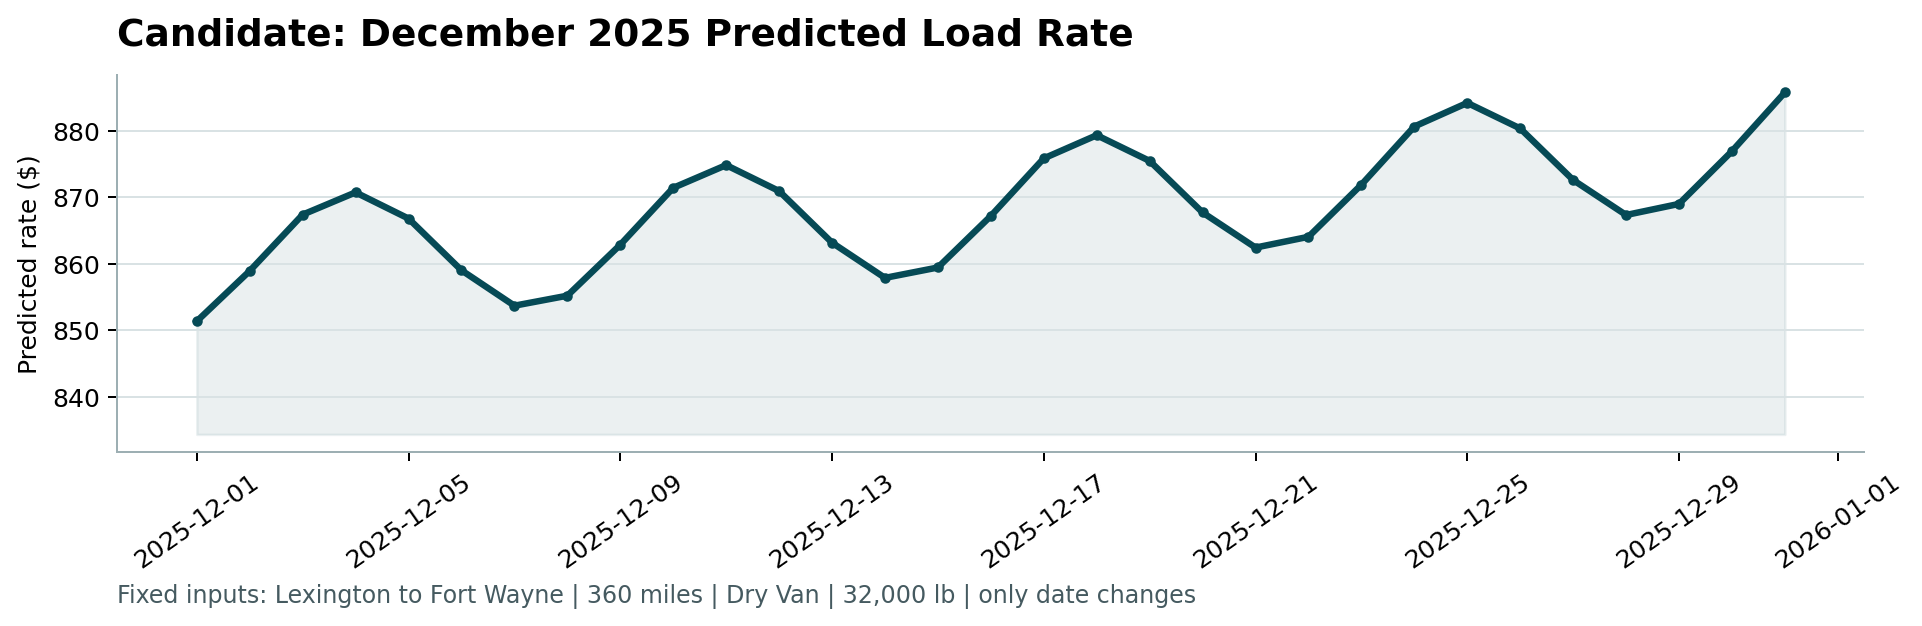

In [43]:
from IPython.display import Image, display

display(Image(filename=str(OUTPUT_DIR / "scorer_results" / "candidate_december.png")))

## 14. Save Final Model Artifacts

Both production models (and the feature lists they expect) are pickled for the repo, so predictions can be regenerated or re-run on new data without rerunning this whole notebook.

In [44]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_artifacts = {
    "model_full": production_model_full,
    "model_no_market": production_model_no_market,
    "full_features": FULL_FEATURES,
    "no_market_features": NO_MARKET_FEATURES,
    "target_transform": "log1p",
    "holdout_metrics_full": final_holdout_metrics,
    "holdout_metrics_no_market": no_market_holdout_metrics,
}

with open(MODELS_DIR / "final_models.pkl", "wb") as f:
    pickle.dump(model_artifacts, f)

print("Saved:", (MODELS_DIR / "final_models.pkl").resolve())

Saved: C:\Users\amc\Desktop\freight-rate-prediction\models\final_models.pkl


## 15. Summary

- **Final model (validation predictions)**: Linear Regression on `log1p(posted_rate)`, using distance, temporal (cyclical), market-signal interaction, equipment one-hot, and target-encoded city features. Trained on all of `train-test.csv` with the flagged rate-per-mile outlier rows excluded.
- **Fallback model (December predictions)**: identical architecture, trained without `market_index`/`quote_signal` and their interaction terms, since `december-chart-inputs.csv` never provides them.
- **Model selection**: four model families (Linear, Ridge, Random Forest, HistGradientBoosting) × raw/log target were compared on a **time-based holdout** (last 6 weeks of training data) rather than a random split, to genuinely test forward-in-time forecasting the same way the real submission is evaluated. Linear Regression on the log target was the most accurate on holdout and is fully interpretable.
- **Known limitation**: the no-market model is measurably less accurate than the full model on holdout (documented in Section 9) — this is the real cost of `december-chart-inputs.csv` missing two of the most informative columns, not a modeling shortfall, and is worth stating plainly in the report/Loom.
- **Outputs produced**: `outputs/validation_predictions.csv`, `outputs/december_predictions.csv`, `outputs/scorer_results/candidate_december.png`, and `models/final_models.pkl`.
